WEEK -5

In [0]:
# -----------------------------------------------------------
#  MILESTONE 3 – WEEK 5: Key Drivers Analysis
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------------------------------------
#  STEP 1: Load Dataset (Your existing correct path)
# -----------------------------------------------------------
DATA_PATH = "/Volumes/workspace/default/netflix_data/eda_processed_netflix.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(" Dataset loaded successfully from:", DATA_PATH)
    print("Shape:", df.shape)
else:
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Please check your upload path.")


 Dataset loaded successfully from: /Volumes/workspace/default/netflix_data/eda_processed_netflix.csv
Shape: (8807, 14)


/home/spark-eef28371-794a-404d-a7da-42/.ipykernel/2491/command-6652936914981284-3597748115:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


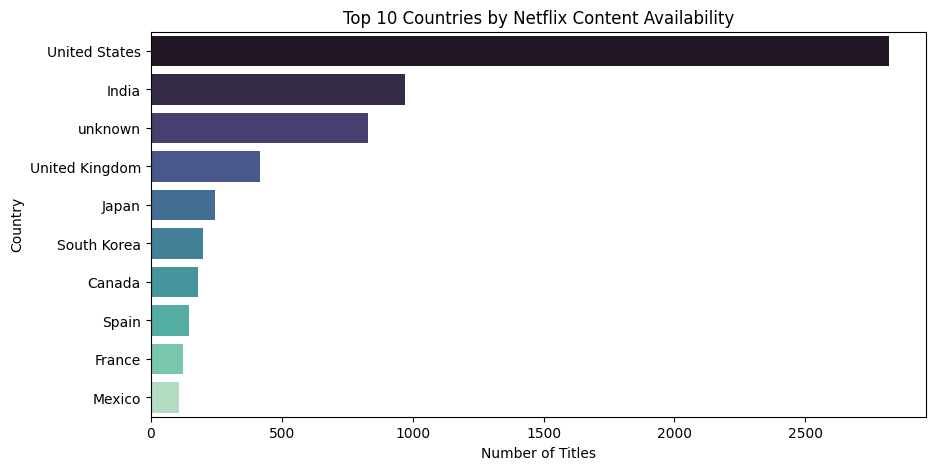

/home/spark-eef28371-794a-404d-a7da-42/.ipykernel/2491/command-6652936914981284-3597748115:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


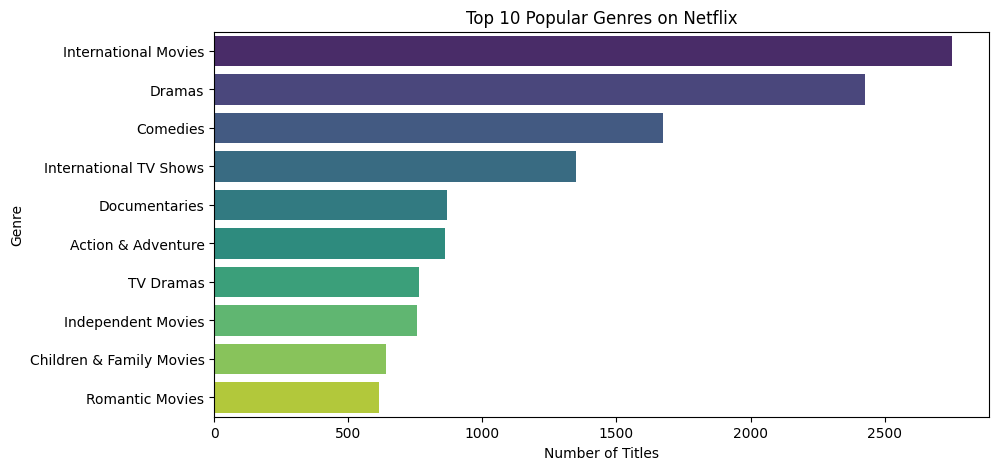

In [0]:
# STEP 2: Basic Data Cleaning
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna(
    subset=[
        "type",
        "country",
        "release_year",
        "listed_in"
    ]
)

# STEP 3: Analyze Key Drivers for Content Availability

# Top 10 countries with most Netflix titles
top_countries = df["country"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="mako"
)
plt.title("Top 10 Countries by Netflix Content Availability")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

# Top 10 genres
top_genres = df["listed_in"].str.split(", ").explode().value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette="viridis"
)
plt.title("Top 10 Popular Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

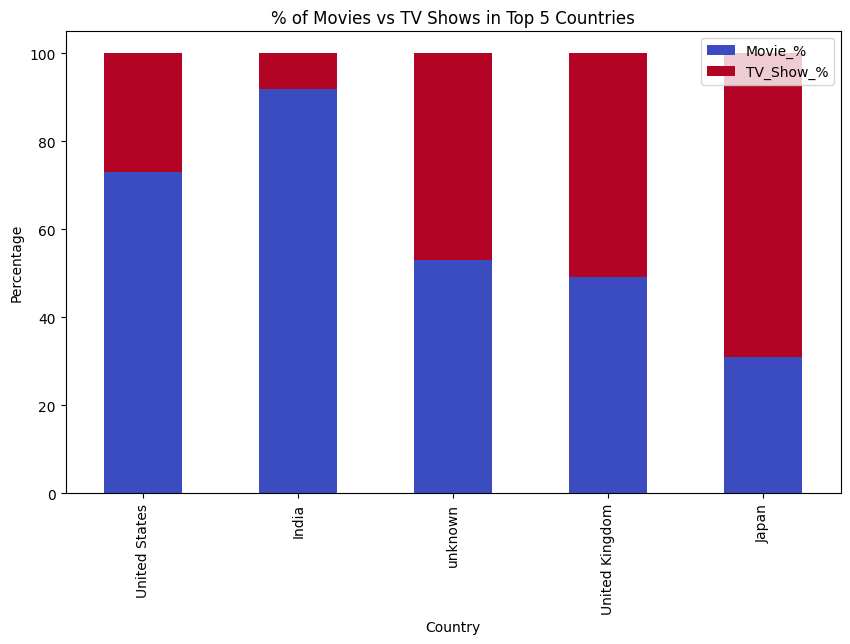

In [0]:
# STEP 4: % of Movies vs TV Shows in Each Country

country_type = (
    df.groupby(["country", "type"])
    .size()
    .unstack(fill_value=0)
)
country_type["Total"] = country_type.sum(axis=1)
country_type["Movie_%"] = (
    country_type.get("Movie", 0) / country_type["Total"] * 100
)
country_type["TV_Show_%"] = (
    country_type.get("TV Show", 0) / country_type["Total"] * 100
)

# Visualize Top 5 countries
top5_country = (
    country_type.sort_values("Total", ascending=False)
    .head(5)[["Movie_%", "TV_Show_%"]]
)
top5_country.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="coolwarm"
)
plt.title("% of Movies vs TV Shows in Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Percentage")
plt.legend(loc="upper right")
plt.show()

/home/spark-eef28371-794a-404d-a7da-42/.ipykernel/2491/command-6652936914981298-2363074589:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trend_data.index, y=trend_data.values, palette="crest")


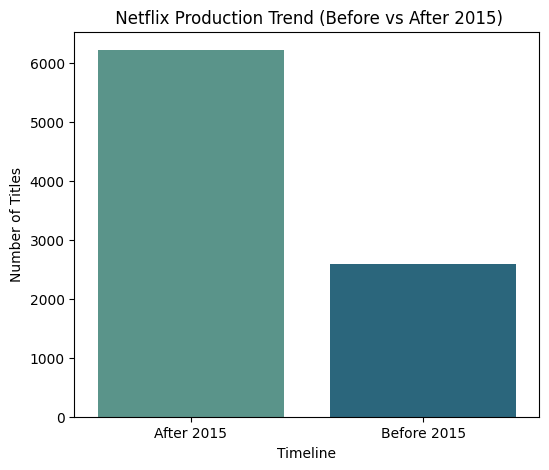

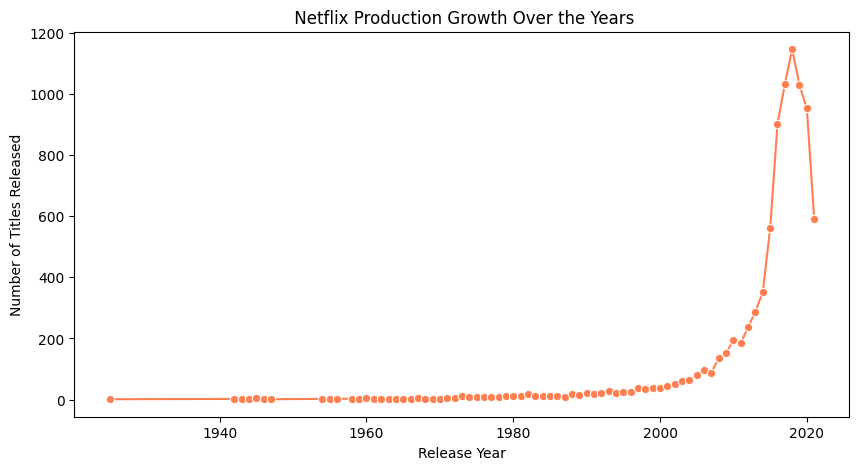

In [0]:

# -----------------------------------------------------------
#  STEP 5: Netflix Production Trend (Before & After 2015)
# -----------------------------------------------------------
df["Before_2015"] = df["release_year"].apply(lambda x: "Before 2015" if x < 2015 else "After 2015")
trend_data = df["Before_2015"].value_counts()

plt.figure(figsize=(6,5))
sns.barplot(x=trend_data.index, y=trend_data.values, palette="crest")
plt.title(" Netflix Production Trend (Before vs After 2015)")
plt.xlabel("Timeline")
plt.ylabel("Number of Titles")
plt.show()

# Yearly production trend
yearly_trend = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker="o", color="coral")
plt.title(" Netflix Production Growth Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles Released")
plt.show()

In [0]:

# -----------------------------------------------------------
#  STEP 6: Summary of Key Drivers
# -----------------------------------------------------------
print("\n📌 Key Insights:")
print("- USA and India dominate Netflix’s content availability.")
print("- The most popular genres are International Movies, Dramas, and Comedies.")
print("- Netflix’s content library grew sharply after 2015, showing global expansion.")
print("- TV Shows increased rapidly post-2015 compared to Movies.")

print("\n Milestone 3 (Week 5) – Key Drivers Analysis completed successfully!")


📌 Key Insights:
- USA and India dominate Netflix’s content availability.
- The most popular genres are International Movies, Dramas, and Comedies.
- Netflix’s content library grew sharply after 2015, showing global expansion.
- TV Shows increased rapidly post-2015 compared to Movies.

 Milestone 3 (Week 5) – Key Drivers Analysis completed successfully!
